<a href="https://colab.research.google.com/github/sadok-belhadj/premier-league-title-race-forecast/blob/main/01_title_race_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 2025/26 Premier League final table:
# initial baseline for the 2026/27 title-race model

table_2025_26 = pd.DataFrame({
    "Team": [
        "Arsenal",
        "Manchester City",
        "Manchester United",
        "Aston Villa",
        "Liverpool"
    ],
    "Played": [38, 38, 38, 38, 38],
    "Won": [26, 23, 20, 19, 17],
    "Drawn": [7, 9, 11, 8, 9],
    "Lost": [5, 6, 7, 11, 12],
    "Goals_For": [71, 77, 69, 56, 63],
    "Goals_Against": [27, 35, 50, 49, 53],
    "Goal_Difference": [44, 42, 19, 7, 10],
    "Points": [85, 78, 71, 65, 60]
})

table_2025_26

,Team,Played,Won,Drawn,Lost,Goals_For,Goals_Against,Goal_Difference,Points
0,Arsenal,38,26,7,5,71,27,44,85
1,Manchester City,38,23,9,6,77,35,42,78
2,Manchester United,38,20,11,7,69,50,19,71
3,Aston Villa,38,19,8,11,56,49,7,65
4,Liverpool,38,17,9,12,63,53,10,60


In [3]:
# Calculate comparable performance measures

table_2025_26["Points_Per_Game"] = (
    table_2025_26["Points"] / table_2025_26["Played"]
)

table_2025_26["Goal_Difference_Per_Game"] = (
    table_2025_26["Goal_Difference"] / table_2025_26["Played"]
)

baseline_ranking = table_2025_26.sort_values(
    by="Points_Per_Game",
    ascending=False
)

baseline_ranking[
    ["Team", "Points", "Points_Per_Game", "Goal_Difference_Per_Game"]
]


,Team,Points,Points_Per_Game,Goal_Difference_Per_Game
0,Arsenal,85,2.236842,1.157895
1,Manchester City,78,2.052632,1.105263
2,Manchester United,71,1.868421,0.500000
3,Aston Villa,65,1.710526,0.184211
4,Liverpool,60,1.578947,0.263158


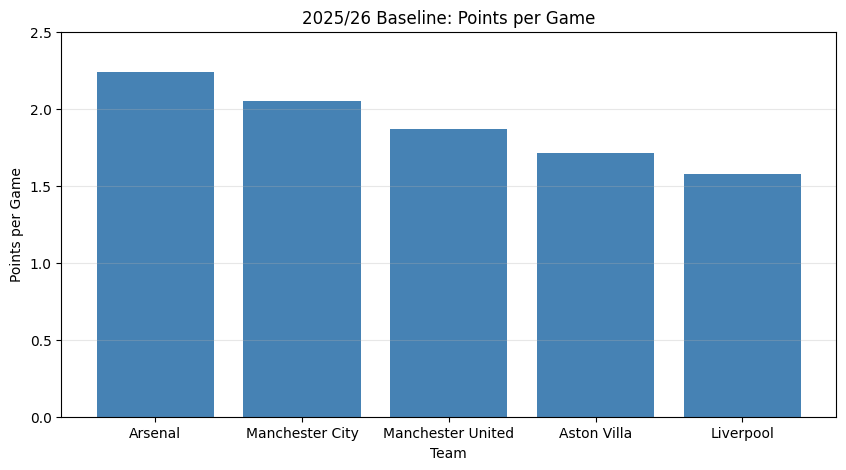

In [4]:
plt.figure(figsize=(10, 5))

plt.bar(
    baseline_ranking["Team"],
    baseline_ranking["Points_Per_Game"],
    color="steelblue"
)

plt.title("2025/26 Baseline: Points per Game")
plt.xlabel("Team")
plt.ylabel("Points per Game")
plt.ylim(0, 2.5)
plt.grid(axis="y", alpha=0.3)

plt.show()


In [5]:
# Scenario adjustments for 2026/27
# Positive = expected improvement; negative = expected decline.
# Keep at zero until each assumption is researched and sourced.

adjustments = pd.DataFrame({
    "Team": baseline_ranking["Team"],
    "Transfer_Adjustment": [0, 0, 0, 0, 0],
    "Manager_Adjustment": [0, 0, 0, 0, 0],
    "Preseason_Adjustment": [0, 0, 0, 0, 0]
})

forecast_inputs = baseline_ranking.merge(adjustments, on="Team")

forecast_inputs


,Team,Played,Won,Drawn,Lost,Goals_For,Goals_Against,Goal_Difference,Points,Points_Per_Game,Goal_Difference_Per_Game,Transfer_Adjustment,Manager_Adjustment,Preseason_Adjustment
0,Arsenal,38,26,7,5,71,27,44,85,2.236842,1.157895,0,0,0
1,Manchester City,38,23,9,6,77,35,42,78,2.052632,1.105263,0,0,0
2,Manchester United,38,20,11,7,69,50,19,71,1.868421,0.500000,0,0,0
3,Aston Villa,38,19,8,11,56,49,7,65,1.710526,0.184211,0,0,0
4,Liverpool,38,17,9,12,63,53,10,60,1.578947,0.263158,0,0,0


In [6]:
# Combined score used as the starting point for the forecast

forecast_inputs["Forecast_Score"] = (
    forecast_inputs["Points_Per_Game"]
    + forecast_inputs["Transfer_Adjustment"]
    + forecast_inputs["Manager_Adjustment"]
    + forecast_inputs["Preseason_Adjustment"]
)

forecast_ranking = forecast_inputs.sort_values(
    by="Forecast_Score",
    ascending=False
)

forecast_ranking[
    [
        "Team",
        "Points_Per_Game",
        "Transfer_Adjustment",
        "Manager_Adjustment",
        "Preseason_Adjustment",
        "Forecast_Score"
    ]
]


,Team,Points_Per_Game,Transfer_Adjustment,Manager_Adjustment,Preseason_Adjustment,Forecast_Score
0,Arsenal,2.236842,0,0,0,2.236842
1,Manchester City,2.052632,0,0,0,2.052632
2,Manchester United,1.868421,0,0,0,1.868421
3,Aston Villa,1.710526,0,0,0,1.710526
4,Liverpool,1.578947,0,0,0,1.578947


In [7]:
# Manager context for 2026/27
# Higher uncertainty will later mean a wider range of simulated outcomes.

manager_context = pd.DataFrame({
    "Team": [
        "Arsenal",
        "Manchester City",
        "Manchester United",
        "Aston Villa",
        "Liverpool"
    ],
    "Manager": [
        "Mikel Arteta",
        "Enzo Maresca",
        "Michael Carrick",
        "Unai Emery",
        "Andoni Iraola"
    ],
    "Manager_Status": [
        "Continuity",
        "New manager",
        "First full season",
        "Continuity",
        "New manager"
    ],
    "Manager_Uncertainty": [
        0.00,
        0.12,
        0.06,
        0.00,
        0.12
    ]
})

forecast_inputs = forecast_inputs.merge(
    manager_context,
    on="Team"
)

forecast_inputs[
    ["Team", "Manager", "Manager_Status", "Manager_Uncertainty"]
]

,Team,Manager,Manager_Status,Manager_Uncertainty
0,Arsenal,Mikel Arteta,Continuity,0.00
1,Manchester City,Enzo Maresca,New manager,0.12
2,Manchester United,Michael Carrick,First full season,0.06
3,Aston Villa,Unai Emery,Continuity,0.00
4,Liverpool,Andoni Iraola,New manager,0.12


In [8]:
import numpy as np

# Simulate 100,000 possible seasons
np.random.seed(42)

n_simulations = 100_000
base_uncertainty = 0.12

teams = forecast_inputs["Team"].to_numpy()
expected_ppg = forecast_inputs["Points_Per_Game"].to_numpy()

# New managers widen the possible range of outcomes;
# they do not automatically improve or reduce the expected score.
simulation_uncertainty = (
    base_uncertainty
    + forecast_inputs["Manager_Uncertainty"].to_numpy()
)

simulated_ppg = np.random.normal(
    loc=expected_ppg,
    scale=simulation_uncertainty,
    size=(n_simulations, len(teams))
)

# Keep simulated points-per-game values realistic
simulated_ppg = np.clip(simulated_ppg, 0, 3)

simulated_points = simulated_ppg * 38
winner_index = np.argmax(simulated_points, axis=1)

title_probabilities = pd.DataFrame({
    "Team": teams,
    "Title_Probability": [
        np.mean(winner_index == i) for i in range(len(teams))
    ]
})

title_probabilities = title_probabilities.sort_values(
    by="Title_Probability",
    ascending=False
)

title_probabilities["Title_Probability"] = (
    title_probabilities["Title_Probability"] * 100
)

title_probabilities


,Team,Title_Probability
0,Arsenal,72.198
1,Manchester City,24.321
2,Manchester United,2.992
4,Liverpool,0.452
3,Aston Villa,0.037


In [9]:
# Add Bournemouth, who finished sixth in 2025/26.
# We will expand to the full 20-team league later.

bournemouth = pd.DataFrame({
    "Team": ["Bournemouth"],
    "Played": [38],
    "Won": [16],
    "Drawn": [9],
    "Lost": [13],
    "Goals_For": [0],          # add verified figures later
    "Goals_Against": [0],      # add verified figures later
    "Goal_Difference": [4],
    "Points": [57]
})

table_2025_26 = pd.concat(
    [table_2025_26, bournemouth],
    ignore_index=True
)

table_2025_26

,Team,Played,Won,Drawn,Lost,Goals_For,Goals_Against,Goal_Difference,Points,Points_Per_Game,Goal_Difference_Per_Game
0,Arsenal,38,26,7,5,71,27,44,85,2.236842,1.157895
1,Manchester City,38,23,9,6,77,35,42,78,2.052632,1.105263
2,Manchester United,38,20,11,7,69,50,19,71,1.868421,0.500000
3,Aston Villa,38,19,8,11,56,49,7,65,1.710526,0.184211
4,Liverpool,38,17,9,12,63,53,10,60,1.578947,0.263158
5,Bournemouth,38,16,9,13,0,0,4,57,NaN,NaN


In [10]:
# Correct Bournemouth's verified 2025/26 figures
# Then recalculate per-game metrics for every team.

table_2025_26.loc[
    table_2025_26["Team"] == "Bournemouth",
    ["Won", "Drawn", "Lost", "Goals_For", "Goals_Against", "Goal_Difference", "Points"]
] = [13, 18, 7, 58, 54, 4, 57]

table_2025_26["Points_Per_Game"] = (
    table_2025_26["Points"] / table_2025_26["Played"]
)

table_2025_26["Goal_Difference_Per_Game"] = (
    table_2025_26["Goal_Difference"] / table_2025_26["Played"]
)

table_2025_26


,Team,Played,Won,Drawn,Lost,Goals_For,Goals_Against,Goal_Difference,Points,Points_Per_Game,Goal_Difference_Per_Game
0,Arsenal,38,26,7,5,71,27,44,85,2.236842,1.157895
1,Manchester City,38,23,9,6,77,35,42,78,2.052632,1.105263
2,Manchester United,38,20,11,7,69,50,19,71,1.868421,0.500000
3,Aston Villa,38,19,8,11,56,49,7,65,1.710526,0.184211
4,Liverpool,38,17,9,12,63,53,10,60,1.578947,0.263158
5,Bournemouth,38,13,18,7,58,54,4,57,1.500000,0.105263


In [11]:
# Rebuild the six-team forecast dataset

baseline_ranking = table_2025_26.sort_values(
    by="Points_Per_Game",
    ascending=False
)

adjustments = pd.DataFrame({
    "Team": baseline_ranking["Team"],
    "Transfer_Adjustment": [0, 0, 0, 0, 0, 0],
    "Manager_Adjustment": [0, 0, 0, 0, 0, 0],
    "Preseason_Adjustment": [0, 0, 0, 0, 0, 0]
})

manager_context = pd.DataFrame({
    "Team": [
        "Arsenal",
        "Manchester City",
        "Manchester United",
        "Aston Villa",
        "Liverpool",
        "Bournemouth"
    ],
    "Manager": [
        "Mikel Arteta",
        "Enzo Maresca",
        "Michael Carrick",
        "Unai Emery",
        "Andoni Iraola",
        "Marco Rose"
    ],
    "Manager_Status": [
        "Continuity",
        "New manager",
        "First full season",
        "Continuity",
        "New manager",
        "New manager"
    ],
    "Manager_Uncertainty": [
        0.00, 0.12, 0.06, 0.00, 0.12, 0.12
    ]
})

forecast_inputs = (
    baseline_ranking
    .merge(adjustments, on="Team")
    .merge(manager_context, on="Team")
)

forecast_inputs["Forecast_Score"] = (
    forecast_inputs["Points_Per_Game"]
    + forecast_inputs["Transfer_Adjustment"]
    + forecast_inputs["Manager_Adjustment"]
    + forecast_inputs["Preseason_Adjustment"]
)

forecast_inputs[
    ["Team", "Points_Per_Game", "Manager", "Manager_Status", "Forecast_Score"]
]


,Team,Points_Per_Game,Manager,Manager_Status,Forecast_Score
0,Arsenal,2.236842,Mikel Arteta,Continuity,2.236842
1,Manchester City,2.052632,Enzo Maresca,New manager,2.052632
2,Manchester United,1.868421,Michael Carrick,First full season,1.868421
3,Aston Villa,1.710526,Unai Emery,Continuity,1.710526
4,Liverpool,1.578947,Andoni Iraola,New manager,1.578947
5,Bournemouth,1.500000,Marco Rose,New manager,1.500000


In [12]:
# Six-team baseline Monte Carlo simulation

np.random.seed(42)

n_simulations = 100_000
base_uncertainty = 0.12

teams = forecast_inputs["Team"].to_numpy()
expected_ppg = forecast_inputs["Forecast_Score"].to_numpy()

simulation_uncertainty = (
    base_uncertainty
    + forecast_inputs["Manager_Uncertainty"].to_numpy()
)

simulated_ppg = np.random.normal(
    loc=expected_ppg,
    scale=simulation_uncertainty,
    size=(n_simulations, len(teams))
)

simulated_ppg = np.clip(simulated_ppg, 0, 3)

winner_index = np.argmax(simulated_ppg, axis=1)

title_probabilities = pd.DataFrame({
    "Team": teams,
    "Title_Probability": [
        np.mean(winner_index == i) * 100
        for i in range(len(teams))
    ]
}).sort_values("Title_Probability", ascending=False)

title_probabilities


,Team,Title_Probability
0,Arsenal,72.326
1,Manchester City,23.889
2,Manchester United,3.117
4,Liverpool,0.463
5,Bournemouth,0.170
3,Aston Villa,0.035


In [13]:
# Confirmed transfer notes as of 13 August 2026
# Do not include rumours in this table.

transfer_notes = pd.DataFrame({
    "Team": [
        "Arsenal",
        "Manchester City",
        "Manchester United",
        "Aston Villa",
        "Liverpool",
        "Bournemouth"
    ],
    "Confirmed_Transfer_Notes": [
        "To be researched",
        "Elliot Anderson signed from Nottingham Forest; further activity to be checked",
        "Youri Tielemans and Andrey Santos signed; further activity to be checked",
        "Youri Tielemans departed to Manchester United; further activity to be checked",
        "Victor Munoz and Jeremy Jacquet signed; further activity to be checked",
        "Marcos Senesi departed to Tottenham; further activity to be checked"
    ],
    "Transfer_Adjustment": [0, 0, 0, 0, 0, 0]
})

transfer_notes

,Team,Confirmed_Transfer_Notes,Transfer_Adjustment
0,Arsenal,To be researched,0
1,Manchester City,Elliot Anderson signed from Nottingham Forest;...,0
2,Manchester United,Youri Tielemans and Andrey Santos signed; furt...,0
3,Aston Villa,Youri Tielemans departed to Manchester United;...,0
4,Liverpool,Victor Munoz and Jeremy Jacquet signed; furthe...,0
5,Bournemouth,Marcos Senesi departed to Tottenham; further a...,0


In [14]:
# Conservative transfer scenario as of 13 August 2026.
# These are model assumptions in PPG, not factual guarantees.

transfer_adjustments = {
    "Arsenal": 0.00,            # review required
    "Manchester City": 0.02,    # Elliot Anderson added
    "Manchester United": 0.05,  # Tielemans + Andrey Santos added
    "Aston Villa": -0.05,       # Tielemans departed
    "Liverpool": 0.00,          # signings and departures currently treated as offsetting
    "Bournemouth": -0.03        # Senesi departed
}

forecast_inputs["Transfer_Adjustment"] = (
    forecast_inputs["Team"].map(transfer_adjustments)
)

forecast_inputs["Forecast_Score"] = (
    forecast_inputs["Points_Per_Game"]
    + forecast_inputs["Transfer_Adjustment"]
    + forecast_inputs["Manager_Adjustment"]
    + forecast_inputs["Preseason_Adjustment"]
)

forecast_inputs[
    ["Team", "Points_Per_Game", "Transfer_Adjustment", "Forecast_Score"]
].sort_values("Forecast_Score", ascending=False)

,Team,Points_Per_Game,Transfer_Adjustment,Forecast_Score
0,Arsenal,2.236842,0.00,2.236842
1,Manchester City,2.052632,0.02,2.072632
2,Manchester United,1.868421,0.05,1.918421
3,Aston Villa,1.710526,-0.05,1.660526
4,Liverpool,1.578947,0.00,1.578947
5,Bournemouth,1.500000,-0.03,1.470000


In [15]:
np.random.seed(42)

n_simulations = 100_000

teams = forecast_inputs["Team"].to_numpy()
expected_ppg = forecast_inputs["Forecast_Score"].to_numpy()

simulation_uncertainty = (
    0.12 + forecast_inputs["Manager_Uncertainty"].to_numpy()
)

simulated_ppg = np.random.normal(
    loc=expected_ppg,
    scale=simulation_uncertainty,
    size=(n_simulations, len(teams))
)

simulated_ppg = np.clip(simulated_ppg, 0, 3)

winner_index = np.argmax(simulated_ppg, axis=1)

title_probabilities = pd.DataFrame({
    "Team": teams,
    "Title_Probability": [
        np.mean(winner_index == i) * 100
        for i in range(len(teams))
    ]
}).sort_values("Title_Probability", ascending=False)

title_probabilities

,Team,Title_Probability
0,Arsenal,68.683
1,Manchester City,25.875
2,Manchester United,4.885
4,Liverpool,0.435
5,Bournemouth,0.114
3,Aston Villa,0.008


In [17]:
# Pre-season form is deliberately low-weight.
# We use it only as a small signal, not as proof of team quality.

preseason_notes = pd.DataFrame({
    "Team": [
        "Arsenal",
        "Manchester City",
        "Manchester United",
        "Aston Villa",
        "Liverpool",
        "Bournemouth"
    ],
    "Preseason_Notes": [
        "To be researched",
        "To be researched",
        "To be researched",
        "To be researched",
        "To be researched",
        "To be researched"
    ],
    "Preseason_Adjustment": [0, 0, 0, 0, 0, 0]
})

preseason_notes

,Team,Preseason_Notes,Preseason_Adjustment
0,Arsenal,To be researched,0
1,Manchester City,To be researched,0
2,Manchester United,To be researched,0
3,Aston Villa,To be researched,0
4,Liverpool,To be researched,0
5,Bournemouth,To be researched,0


In [18]:
# Forecast summary: as of 13 August 2026
# Important: this is a preliminary six-team contender model.
# It is not yet a full 20-team, fixture-by-fixture forecast.

forecast_summary = forecast_inputs[
    [
        "Team",
        "Points_Per_Game",
        "Transfer_Adjustment",
        "Manager_Uncertainty",
        "Preseason_Adjustment",
        "Forecast_Score"
    ]
].copy()

forecast_summary["Expected_Points_Over_38_Games"] = (
    forecast_summary["Forecast_Score"] * 38
)

forecast_summary = forecast_summary.sort_values(
    "Expected_Points_Over_38_Games",
    ascending=False
)

forecast_summary

,Team,Points_Per_Game,Transfer_Adjustment,Manager_Uncertainty,Preseason_Adjustment,Forecast_Score,Expected_Points_Over_38_Games
0,Arsenal,2.236842,0.00,0.00,0,2.236842,85.00
1,Manchester City,2.052632,0.02,0.12,0,2.072632,78.76
2,Manchester United,1.868421,0.05,0.06,0,1.918421,72.90
3,Aston Villa,1.710526,-0.05,0.00,0,1.660526,63.10
4,Liverpool,1.578947,0.00,0.12,0,1.578947,60.00
5,Bournemouth,1.500000,-0.03,0.12,0,1.470000,55.86


## Preliminary forecast — 13 August 2026

This initial six-team model projects Arsenal as the strongest title contender, followed by Manchester City and Manchester United.

The forecast starts from 2025/26 points per game, then applies small, transparent transfer adjustments. New-manager situations increase uncertainty in the Monte Carlo simulation rather than automatically improving or reducing a team’s score.

### Limitations

- Only six teams are currently included.
- The transfer window remains open until 1 September 2026.
- Pre-season results are currently assigned zero weight.
- Injuries, fixtures and the remaining 14 teams are not yet included.

This is an educational forecasting project, not betting advice or a guarantee of outcomes.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
# Full 2026/27 Premier League baseline
# Promoted clubs receive a cautious Premier League estimate,
# not their raw Championship points per game.

league_baseline = pd.DataFrame({
    "Team": [
        "Arsenal", "Manchester City", "Manchester United",
        "Aston Villa", "Liverpool", "Bournemouth",
        "Sunderland", "Brighton", "Brentford", "Chelsea",
        "Fulham", "Newcastle United", "Everton", "Leeds United",
        "Crystal Palace", "Nottingham Forest", "Tottenham Hotspur",
        "Coventry City", "Ipswich Town", "Hull City"
    ],
    "Source_League": [
        "Premier League"] * 17 + ["Championship"] * 3,
    "Previous_Points": [
        85, 78, 71, 65, 60, 57,
        54, 53, 53, 52,
        52, 49, 49, 47,
        45, 44, 41,
        95, 84, 73
    ],
    "Previous_Goal_Difference": [
        44, 42, 19, 7, 10, 4,
        -6, 6, 3, 6,
        4, -2, -3, -7,
        -10, -3, -9,
        52, 33, 4
    ],
    "Previous_Games": [
        38] * 17 + [46] * 3,
    "Promoted": [
        False] * 17 + [True] * 3
})

league_baseline["Previous_Points_Per_Game"] = (
    league_baseline["Previous_Points"]
    / league_baseline["Previous_Games"]
)

# Conservative Premier League starting estimate for promoted teams.
# This is an explicit modelling assumption, not a historical fact.
league_baseline["Baseline_PPG_2026_27"] = (
    league_baseline["Previous_Points_Per_Game"]
)

league_baseline.loc[
    league_baseline["Promoted"],
    "Baseline_PPG_2026_27"
] = [1.15, 1.10, 0.95]

league_baseline.sort_values(
    "Baseline_PPG_2026_27",
    ascending=False
)[
    [
        "Team",
        "Source_League",
        "Promoted",
        "Previous_Points_Per_Game",
        "Baseline_PPG_2026_27"
    ]
]

,Team,Source_League,Promoted,Previous_Points_Per_Game,Baseline_PPG_2026_27
0,Arsenal,Premier League,False,2.236842,2.236842
1,Manchester City,Premier League,False,2.052632,2.052632
2,Manchester United,Premier League,False,1.868421,1.868421
3,Aston Villa,Premier League,False,1.710526,1.710526
4,Liverpool,Premier League,False,1.578947,1.578947
5,Bournemouth,Premier League,False,1.500000,1.500000
6,Sunderland,Premier League,False,1.421053,1.421053
7,Brighton,Premier League,False,1.394737,1.394737
8,Brentford,Premier League,False,1.394737,1.394737
9,Chelsea,Premier League,False,1.368421,1.368421


In [7]:
# Manager and promotion uncertainty for the full 2026/27 model

manager_uncertainty = {
    "Arsenal": 0.06,
    "Manchester City": 0.12,
    "Manchester United": 0.08,
    "Aston Villa": 0.06,
    "Liverpool": 0.12,
    "Bournemouth": 0.12,
    "Sunderland": 0.07,
    "Brighton": 0.07,
    "Brentford": 0.08,
    "Chelsea": 0.12,
    "Fulham": 0.12,
    "Newcastle United": 0.06,
    "Everton": 0.07,
    "Leeds United": 0.07,
    "Crystal Palace": 0.12,
    "Nottingham Forest": 0.12,
    "Tottenham Hotspur": 0.12,
    "Coventry City": 0.16,
    "Ipswich Town": 0.16,
    "Hull City": 0.16
}

league_baseline["Manager_Uncertainty"] = (
    league_baseline["Team"].map(manager_uncertainty)
)

# No positive/negative transfer or pre-season effects yet
league_baseline["Transfer_Adjustment"] = 0.0
league_baseline["Preseason_Adjustment"] = 0.0

league_baseline["Forecast_PPG"] = (
    league_baseline["Baseline_PPG_2026_27"]
    + league_baseline["Transfer_Adjustment"]
    + league_baseline["Preseason_Adjustment"]
)

league_baseline[
    [
        "Team",
        "Promoted",
        "Baseline_PPG_2026_27",
        "Manager_Uncertainty",
        "Forecast_PPG"
    ]
].sort_values("Forecast_PPG", ascending=False)

,Team,Promoted,Baseline_PPG_2026_27,Manager_Uncertainty,Forecast_PPG
0,Arsenal,False,2.236842,0.06,2.236842
1,Manchester City,False,2.052632,0.12,2.052632
2,Manchester United,False,1.868421,0.08,1.868421
3,Aston Villa,False,1.710526,0.06,1.710526
4,Liverpool,False,1.578947,0.12,1.578947
5,Bournemouth,False,1.500000,0.12,1.500000
6,Sunderland,False,1.421053,0.07,1.421053
7,Brighton,False,1.394737,0.07,1.394737
8,Brentford,False,1.394737,0.08,1.394737
9,Chelsea,False,1.368421,0.12,1.368421


In [8]:
# Full 20-team preliminary Monte Carlo title forecast

np.random.seed(42)

n_simulations = 100_000
base_uncertainty = 0.12

teams = league_baseline["Team"].to_numpy()
expected_ppg = league_baseline["Forecast_PPG"].to_numpy()

simulation_uncertainty = (
    base_uncertainty
    + league_baseline["Manager_Uncertainty"].to_numpy()
)

simulated_ppg = np.random.normal(
    loc=expected_ppg,
    scale=simulation_uncertainty,
    size=(n_simulations, len(teams))
)

simulated_ppg = np.clip(simulated_ppg, 0, 3)

simulated_points = simulated_ppg * 38
winner_index = np.argmax(simulated_points, axis=1)

full_title_probabilities = pd.DataFrame({
    "Team": teams,
    "Title_Probability": [
        np.mean(winner_index == i) * 100
        for i in range(len(teams))
    ]
}).sort_values("Title_Probability", ascending=False)

full_title_probabilities.head(10)

,Team,Title_Probability
0,Arsenal,68.385
1,Manchester City,24.933
2,Manchester United,4.973
3,Aston Villa,0.675
4,Liverpool,0.604
5,Bournemouth,0.271
10,Fulham,0.048
9,Chelsea,0.046
17,Coventry City,0.025
6,Sunderland,0.011


In [9]:
# Match-by-match full-season simulation
# Every pair of teams plays twice: once home, once away.

np.random.seed(42)

def simulate_match(home_rating, away_rating):
    # Home advantage is modest; higher rating increases win chance.
    rating_difference = (home_rating - away_rating) + 55

    home_win_given_no_draw = 1 / (1 + np.exp(-rating_difference / 180))
    draw_probability = 0.25

    home_win_probability = (
        (1 - draw_probability) * home_win_given_no_draw
    )
    away_win_probability = (
        (1 - draw_probability) * (1 - home_win_given_no_draw)
    )

    outcome = np.random.choice(
        ["home", "draw", "away"],
        p=[
            home_win_probability,
            draw_probability,
            away_win_probability
        ]
    )

    return outcome


# Convert forecast PPG into a relative team-strength rating
league_average_ppg = league_baseline["Forecast_PPG"].mean()

league_baseline["Strength_Rating"] = (
    (league_baseline["Forecast_PPG"] - league_average_ppg) * 400
)

teams = league_baseline["Team"].tolist()
ratings = dict(
    zip(league_baseline["Team"], league_baseline["Strength_Rating"])
)

n_simulations = 20_000
title_wins = {team: 0 for team in teams}

for simulation in range(n_simulations):
    points = {team: 0 for team in teams}

    for home_team in teams:
        for away_team in teams:
            if home_team == away_team:
                continue

            result = simulate_match(
                ratings[home_team],
                ratings[away_team]
            )

            if result == "home":
                points[home_team] += 3
            elif result == "away":
                points[away_team] += 3
            else:
                points[home_team] += 1
                points[away_team] += 1

    champion = max(points, key=points.get)
    title_wins[champion] += 1

match_simulation_results = pd.DataFrame({
    "Team": teams,
    "Title_Probability": [
        title_wins[team] / n_simulations * 100
        for team in teams
    ]
}).sort_values("Title_Probability", ascending=False)

match_simulation_results.head(10)

,Team,Title_Probability
0,Arsenal,63.925
1,Manchester City,25.965
2,Manchester United,7.775
3,Aston Villa,1.795
4,Liverpool,0.335
5,Bournemouth,0.105
6,Sunderland,0.035
8,Brentford,0.020
9,Chelsea,0.015
7,Brighton,0.010


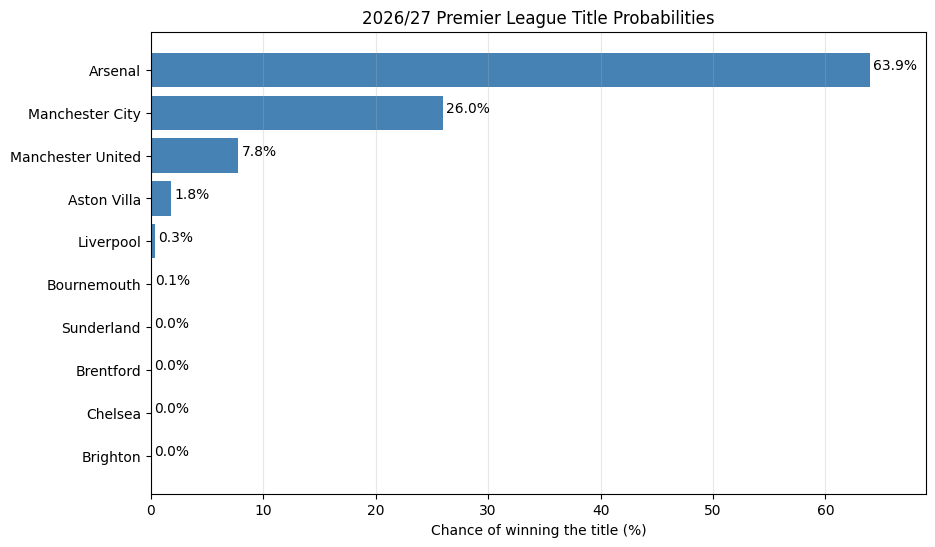

In [10]:
plot_data = match_simulation_results.head(10).sort_values(
    "Title_Probability"
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_data["Team"],
    plot_data["Title_Probability"],
    color="steelblue"
)

plt.title("2026/27 Premier League Title Probabilities")
plt.xlabel("Chance of winning the title (%)")
plt.xlim(0, plot_data["Title_Probability"].max() + 5)
plt.grid(axis="x", alpha=0.3)

for index, value in enumerate(plot_data["Title_Probability"]):
    plt.text(value + 0.3, index, f"{value:.1f}%")

plt.show()

## Interpretation

Based on the model’s baseline performance estimates and simulated home-and-away fixtures:

- Arsenal have the highest estimated title probability (63.9%).
- Manchester City are the main challenger (26.0%).
- Manchester United are an outside contender (7.8%).
- The remaining teams have low title probabilities in this version of the model.

## Limitations

This is an educational forecasting model, not betting advice. It uses previous-season performance as the main baseline, with simplified assumptions for promoted teams, managerial uncertainty and home advantage.

It does not yet fully model injuries, future transfers, tactical changes, fixture timing, European competition, or individual player performance. Results should be interpreted as model outputs under these assumptions rather than certain predictions.